<a href="https://colab.research.google.com/github/NishanRegmi/Deep-Learning/blob/main/vanishing_gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In machine learning, the vanishing gradient problem is encountered when training artificial neural netwroks with gradient-base learning methods and backpropagation. In such methods, during each iteration of training each of the neural network's weights receives an update proportional to the partial derivative of the error function with respect to current weight. The problem is that in some cases, the gradient will be vanishingly small, effectively preventing the weight from changing its value. In worst case, this may completely stop the neural network from further traning.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras import Sequential
from keras.layers import Dense

In [25]:
X, y = make_moons(n_samples=250, noise=0.05, random_state=41)

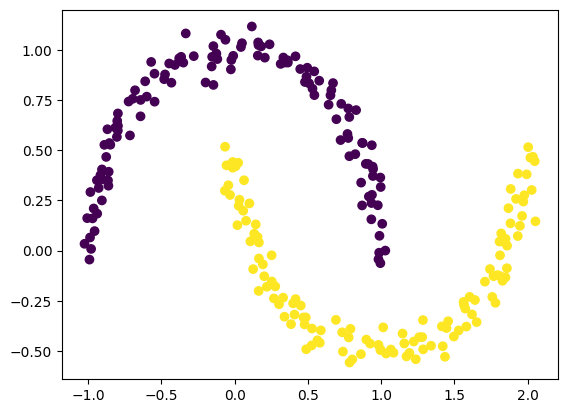

In [26]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [27]:
model = Sequential()

In [5]:
model.add(Dense(10, activation='sigmoid', input_dim=2))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
old_weights = model.get_weights()[0]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=41)

In [17]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5100 - loss: 0.6931
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5100 - loss: 0.6930
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5100 - loss: 0.6931
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5100 - loss: 0.6930
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5100 - loss: 0.6930
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5100 - loss: 0.6929
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5100 - loss: 0.6932
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5100 - loss: 0.6932
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5100 - loss: 0.6930
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5100 - loss: 0.6932


In [18]:
new_weights = model.get_weights()[0]

In [12]:
new_weights

array([[ 0.48837   , -0.2079335 , -0.49496925,  0.28424183,  0.2918205 ,
        -0.02190715,  0.4747783 , -0.03548386,  0.23717727,  0.51360047],
       [-0.2606638 ,  0.16497307, -0.53972566, -0.6942705 , -0.283545  ,
        -0.4782839 , -0.07430408, -0.5437263 ,  0.26752174, -0.4851331 ]],
      dtype=float32)

In [19]:
old_weights

array([[ 0.48836178, -0.20793283, -0.49496955,  0.2842328 ,  0.2918145 ,
        -0.02190644,  0.47477788, -0.03548414,  0.2371701 ,  0.51360685],
       [-0.2606572 ,  0.16497254, -0.5397254 , -0.6942641 , -0.28354055,
        -0.47828445, -0.07430369, -0.543726  ,  0.2675268 , -0.48513803]],
      dtype=float32)

In [20]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [21]:
gradient = (old_weights-new_weights)/0.001
percentage_change = abs(100*(old_weights-new_weights)/old_weights)

In [22]:
gradient

array([[-0.28434396,  0.02112984, -0.01746416, -0.3003776 , -0.2029538 ,
         0.03451109, -0.0218153 , -0.01228973, -0.25001168,  0.2285242 ],
       [ 0.23901461, -0.01719594,  0.01275539,  0.21988152,  0.15714763,
        -0.02607703,  0.01955777,  0.01400709,  0.18540023, -0.18253921]],
      dtype=float32)

In [23]:
percentage_change

array([[0.05822404, 0.01016186, 0.00352833, 0.10568014, 0.06954891,
        0.1575386 , 0.00459484, 0.03463444, 0.1054145 , 0.044494  ],
       [0.09169693, 0.01042352, 0.00236331, 0.03167117, 0.05542334,
        0.0054522 , 0.02632141, 0.00257613, 0.06930156, 0.03762624]],
      dtype=float32)

Vanishing gradient means, partial derivative with respect to weight becomes extremly small. Ultimately, change in weight becomes negligable.

**How to handle vanishing gradient problem?**

1. Reduce model complexity.

2. Use ReLU activation function.

3. Proper weight initialization.

4. Batch normalization.

5. Using Residual Networks.

In [ ]:
#Reducing model complexity by removing hidden layers.

In [28]:
model = Sequential()

In [29]:
model.add(Dense(10, activation='sigmoid', input_dim=2))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [32]:
old_weights = model.get_weights()[0]

In [33]:
model.fit(X_train, y_train, epochs=50)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.4900 - loss: 0.6889
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6871 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7800 - loss: 0.6854 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7850 - loss: 0.6848 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8000 - loss: 0.6841 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7900 - loss: 0.6835 
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8000 - loss: 0.6828 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8050 - loss: 0.6823 
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8200 - loss: 0.6811 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8100 - loss: 0.6806 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8250 - loss: 0.6798 
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8250 - loss: 0.6790 
E

In [34]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [35]:
new_weights = model.get_weights()[0]

In [36]:
gradient = (old_weights-new_weights)/0.001
percentage_change = abs(100*(old_weights-new_weights)/old_weights)

In [37]:
gradient

array([[ 464.86792,  402.22784, -466.64856, -441.02942,  396.71573,
         372.01236, -469.02325,  445.4002 , -385.11053, -443.0512 ],
       [-513.02875, -452.5527 ,  471.53976,  459.84515, -444.13065,
        -397.99802,  536.69354, -481.5834 ,  444.28986,  500.16882]],
      dtype=float32)

In [38]:
percentage_change

array([[ 136.59007 ,   78.24485 ,   98.7605  ,  160.17769 ,   85.95721 ,
         260.68472 ,   96.06252 ,  986.2235  ,   62.150364,   98.63233 ],
       [ 563.4271  ,  266.2714  ,  113.46909 ,   87.693665,  153.19116 ,
          99.08635 , 2080.8381  ,  123.8333  ,   99.76568 ,  204.61325 ]],
      dtype=float32)

In [39]:
old_weights

array([[-0.340338  , -0.51406306, -0.47250527, -0.2753376 , -0.46152705,
        -0.14270586,  0.48824793, -0.0451622 ,  0.6196433 ,  0.44919473],
       [ 0.09105504, -0.16995919, -0.41556674, -0.52437675,  0.28991926,
         0.4016679 , -0.02579218,  0.38889652, -0.44533336, -0.24444598]],
      dtype=float32)

In [40]:
new_weights

array([[-0.80520594, -0.91629094, -0.0058567 ,  0.16569182, -0.8582428 ,
        -0.51471823,  0.9572712 , -0.49056244,  1.0047538 ,  0.89224595],
       [ 0.60408384,  0.28259355, -0.88710654, -0.98422194,  0.7340499 ,
         0.7996659 , -0.56248575,  0.87047994, -0.8896232 , -0.74461484]],
      dtype=float32)

#using ReLU activatio function

In [51]:
model = Sequential()

In [52]:
model.add(Dense(10, activation='relu', input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [54]:
old_weights = model.get_weights()[0]

In [55]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.4900 - loss: 0.6929
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6905 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7150 - loss: 0.6866 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8400 - loss: 0.6814 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8400 - loss: 0.6737 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8250 - loss: 0.6619 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8350 - loss: 0.6452 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8250 - loss: 0.6226 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8250 - loss: 0.5944 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8300 - loss: 0.5638 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8350 - loss: 0.5350 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8450 - lo

In [56]:
new_weights = model.get_weights()[0]

In [57]:
old_weights

array([[ 0.6894329 ,  0.55370134,  0.5625846 ,  0.68772155, -0.41498983,
        -0.29713932, -0.03758013, -0.58410054, -0.49796197,  0.06047535],
       [-0.18940324,  0.4529062 , -0.544674  ,  0.08114314,  0.0027414 ,
        -0.36651793, -0.18352944, -0.285775  , -0.5094691 ,  0.6730531 ]],
      dtype=float32)

In [58]:
new_weights

array([[ 0.8182393 ,  0.52249074,  0.63400954,  0.74633664, -0.6231317 ,
        -0.28718522, -0.06832682, -0.69552857, -0.54846525,  0.12102823],
       [-0.28485173,  0.48363814, -0.6484257 ,  0.05040028,  0.14195421,
        -0.1858943 , -0.14058465, -0.19547984, -0.2729045 ,  0.8553534 ]],
      dtype=float32)